# Bound Validation: Observed vs Theoretical Worst-Case

Two experiments that run many simulations and compare observed outcomes to the theoretical bounds proved in the paper.

- **Experiment 1**: Worst-case monetary loss vs bound ($b\ln n$ for LMSR, $b$ for CFMM)
- **Experiment 2**: Worst-case information loss ($D_{\rm KL}(p^* \| p_{\rm final})$) vs prior bound ($\ln n - H(p^*)$)

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json

sys.path.insert(0, '.')
from MarketSim.marketmaker import LMSR, CFMM
from MarketSim.market import Market

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

# ── Parameters ──────────────────────────────────────────────────────────────
B = 50
N_VALS = [2, 4, 8, 16]
N_RUNS = 200
T = 500

NOISE_CONFIGS = [
    dict(noise_ratio=0.9, confidence=0.8, label='Adversarial (90% noise, conf=0.8)'),
    dict(noise_ratio=0.3, confidence=0.1, label='Normal (30% noise, conf=0.1)'),
]

COLORS = {'LMSR': '#4C72B0', 'CFMM': '#DD8452'}

def make_true_p(n):
    p = np.ones(n) / n
    p[0] += 0.2
    p /= p.sum()
    return p

print('Setup complete.')
print(f'n values: {N_VALS}, b={B}, k=b^n')
for n in N_VALS:
    p = make_true_p(n)
    print(f'  n={n:2d}: true_p[0]={p[0]:.3f}, theoretical LMSR bound={B*np.log(n):.2f}, CFMM bound={B:.2f}')

Setup complete.
n values: [2, 4, 8, 16], b=50, k=b^n
  n= 2: true_p[0]=0.583, theoretical LMSR bound=34.66, CFMM bound=50.00
  n= 4: true_p[0]=0.375, theoretical LMSR bound=69.31, CFMM bound=50.00
  n= 8: true_p[0]=0.271, theoretical LMSR bound=103.97, CFMM bound=50.00
  n=16: true_p[0]=0.219, theoretical LMSR bound=138.63, CFMM bound=50.00


## Simulation Loop

We run all simulations here and collect both monetary loss and information loss for each run.
This cell is the only one that takes significant time (~2–5 minutes).

In [2]:
# results[noise_label][amm_name][n] = list of (monetary_loss, info_loss) tuples
results = {cfg['label']: {'LMSR': {str(n): [] for n in N_VALS},
                          'CFMM': {str(n): [] for n in N_VALS}}
           for cfg in NOISE_CONFIGS}

for cfg in NOISE_CONFIGS:
    noise_label = cfg['label']
    nr = cfg['noise_ratio']
    conf = cfg['confidence']
    for n in N_VALS:
        k = B ** n
        true_p = make_true_p(n)
        for amm_name, amm_cls, amm_kw in [
            ('LMSR', LMSR, {'b': B}),
            ('CFMM', CFMM, {'k_constant': k}),
        ]:
            for _ in range(N_RUNS):
                amm = amm_cls(n, **amm_kw)
                market = Market(amm, T, true_p, nr, agent_confidence=conf)
                price_hist, _, _, realized = market.run()

                # Monetary loss: positive = AMM lost money
                monetary_loss = -realized  # loss = -(collected - q_winner)

                # Information loss: D_KL(p* || p_final)
                p_final = np.clip(price_hist[-1], 1e-12, 1.0)
                p_final /= p_final.sum()  # renormalize after clip
                info_loss = float(np.sum(true_p * np.log(true_p / p_final)))

                results[noise_label][amm_name][str(n)].append((monetary_loss, info_loss))

        print(f'[{noise_label[:12]}] n={n} done')

# Save results
with open('bound_verification.json', 'w') as f:
    json.dump(results, f, indent=4)

print('\nAll simulations complete.')

[Adversarial ] n=2 done
[Adversarial ] n=4 done
[Adversarial ] n=8 done
[Adversarial ] n=16 done
[Normal (30% ] n=2 done
[Normal (30% ] n=4 done
[Normal (30% ] n=8 done
[Normal (30% ] n=16 done

All simulations complete.


## Experiment 1: Worst-Case Monetary Loss

**Theoretical bounds**:
- LMSR: $L_{\max} = b\ln n$
- CFMM ($k=b^n$): $L_{\max} = k^{1/n} = b$ (constant in $n$)

The bound should **never be exceeded** — violin plots show the full distribution and the ceiling.
Note: negative values mean the AMM profited on that run.

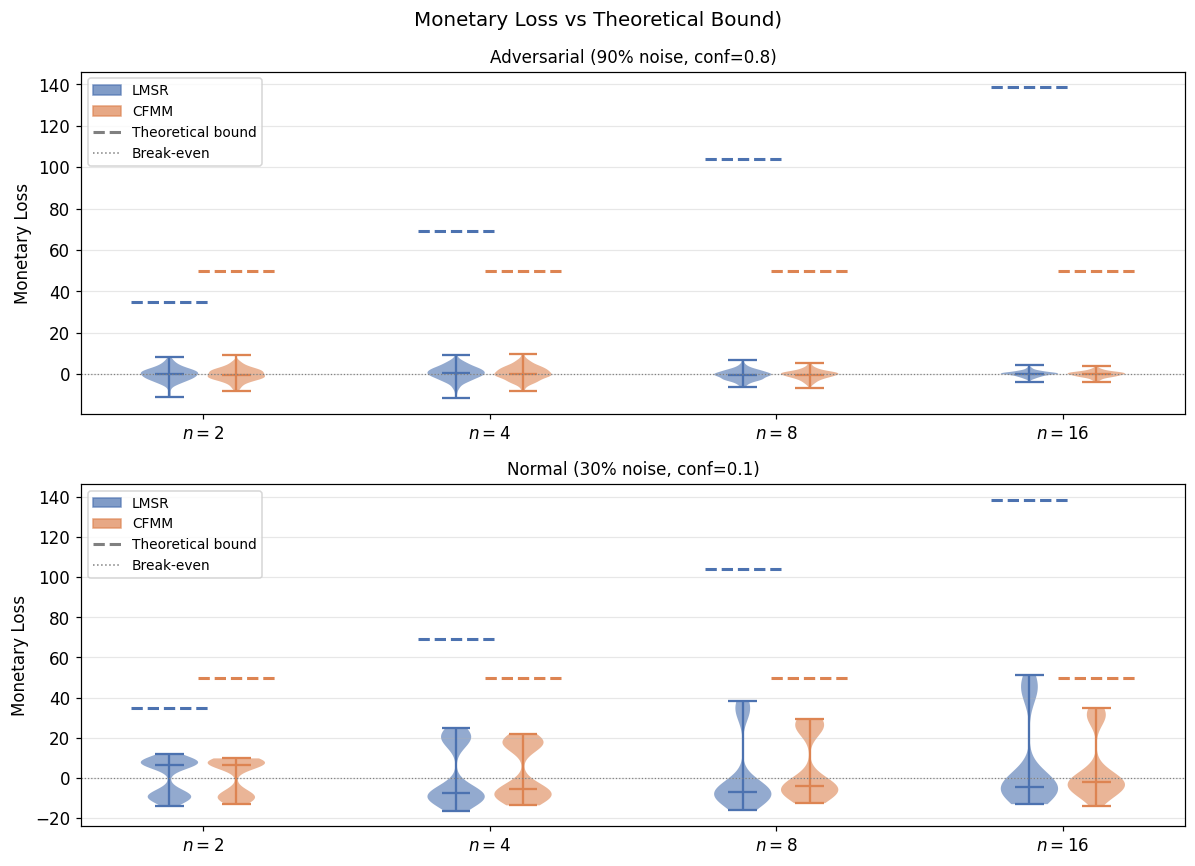


Worst-case monetary loss verification (should be <= bound):
   n |   LMSR bound | LMSR max obs |   CFMM bound | CFMM max obs | regime
------------------------------------------------------------------------
   2 |       34.657 |       8.186✓ |       50.000 |       9.249✓ | Adversarial (90% noi
   4 |       69.315 |       9.474✓ |       50.000 |       9.512✓ | Adversarial (90% noi
   8 |      103.972 |       6.720✓ |       50.000 |       5.391✓ | Adversarial (90% noi
  16 |      138.629 |       4.618✓ |       50.000 |       4.190✓ | Adversarial (90% noi
   2 |       34.657 |      11.830✓ |       50.000 |       9.776✓ | Normal (30% noise, c
   4 |       69.315 |      25.049✓ |       50.000 |      21.913✓ | Normal (30% noise, c
   8 |      103.972 |      38.552✓ |       50.000 |      29.464✓ | Normal (30% noise, c
  16 |      138.629 |      51.068✓ |       50.000 |      34.710✓ | Normal (30% noise, c


In [40]:
fig, axes = plt.subplots(len(NOISE_CONFIGS), 1, figsize=(11, 8), sharex=False)

for ax, cfg in zip(axes, NOISE_CONFIGS):
    noise_label = cfg['label']
    positions_lmsr = []
    positions_cfmm = []
    data_lmsr = []
    data_cfmm = []
    x_ticks = []
    x_labels = []

    gap = 0.35
    for i, n in enumerate(N_VALS):
        base = i * 1.5
        positions_lmsr.append(base)
        positions_cfmm.append(base + gap)
        data_lmsr.append([r[0] for r in results[noise_label]['LMSR'][str(n)]])
        data_cfmm.append([r[0] for r in results[noise_label]['CFMM'][str(n)]])
        x_ticks.append(base + gap / 2)
        x_labels.append(f'$n={n}$')

    vl = ax.violinplot(data_lmsr, positions=positions_lmsr, widths=0.3,
                       showmedians=True, showextrema=True)
    vc = ax.violinplot(data_cfmm, positions=positions_cfmm, widths=0.3,
                       showmedians=True, showextrema=True)

    for body in vl['bodies']:
        body.set_facecolor(COLORS['LMSR'])
        body.set_alpha(0.6)
    for key in ['cmedians', 'cmins', 'cmaxes', 'cbars']:
        vl[key].set_color(COLORS['LMSR'])

    for body in vc['bodies']:
        body.set_facecolor(COLORS['CFMM'])
        body.set_alpha(0.6)
    for key in ['cmedians', 'cmins', 'cmaxes', 'cbars']:
        vc[key].set_color(COLORS['CFMM'])

    # Theoretical bounds
    for i, n in enumerate(N_VALS):
        base = i * 1.5
        lmsr_bound = B * np.log(n)
        cfmm_bound = float(B)  # k^(1/n) = (b^n)^(1/n) = b
        ax.hlines(lmsr_bound, base - 0.2, base + 0.2,
                  colors=COLORS['LMSR'], linestyles='--', lw=2)
        ax.hlines(cfmm_bound, base + gap - 0.2, base + gap + 0.2,
                  colors=COLORS['CFMM'], linestyles='--', lw=2)

    ax.axhline(0, color='gray', lw=0.8, ls=':')
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels)
    ax.set_ylabel('Monetary Loss', fontsize=11)
    ax.set_title(noise_label, fontsize=11)
    ax.grid(True, axis='y', alpha=0.3)

    lmsr_patch = mpatches.Patch(color=COLORS['LMSR'], alpha=0.7, label='LMSR')
    cfmm_patch = mpatches.Patch(color=COLORS['CFMM'], alpha=0.7, label='CFMM')
    bound_line = plt.Line2D([0], [0], color='gray', ls='--', lw=2, label='Theoretical bound')
    zero_line = plt.Line2D([0], [0], color='gray', ls=':', lw=1, label='Break-even')
    ax.legend(handles=[lmsr_patch, cfmm_patch, bound_line, zero_line], fontsize=9, loc='upper left')

plt.suptitle(f'Monetary Loss vs Theoretical Bound', fontsize=13)
plt.tight_layout()
plt.savefig('fig_bound_monetary.png', dpi=150, bbox_inches='tight')
plt.show()

# Verification table
print('\nWorst-case monetary loss verification (should be <= bound):')
print(f'{"n":>4} | {"LMSR bound":>12} | {"LMSR max obs":>12} | {"CFMM bound":>12} | {"CFMM max obs":>12} | regime')
print('-' * 72)
for cfg in NOISE_CONFIGS:
    nl = cfg['label']
    for n in N_VALS:
        lmsr_obs = max([r[0] for r in results[nl]['LMSR'][str(n)]])
        cfmm_obs = max([r[0] for r in results[nl]['CFMM'][str(n)]])
        lmsr_bd = B * np.log(n)
        cfmm_bd = float(B)
        ok_l = '✓' if lmsr_obs <= lmsr_bd else '✗ VIOLATED'
        ok_c = '✓' if cfmm_obs <= cfmm_bd else '✗ VIOLATED'
        print(f'{n:>4} | {lmsr_bd:>12.3f} | {lmsr_obs:>11.3f}{ok_l} | {cfmm_bd:>12.3f} | {cfmm_obs:>11.3f}{ok_c} | {nl[:20]}')